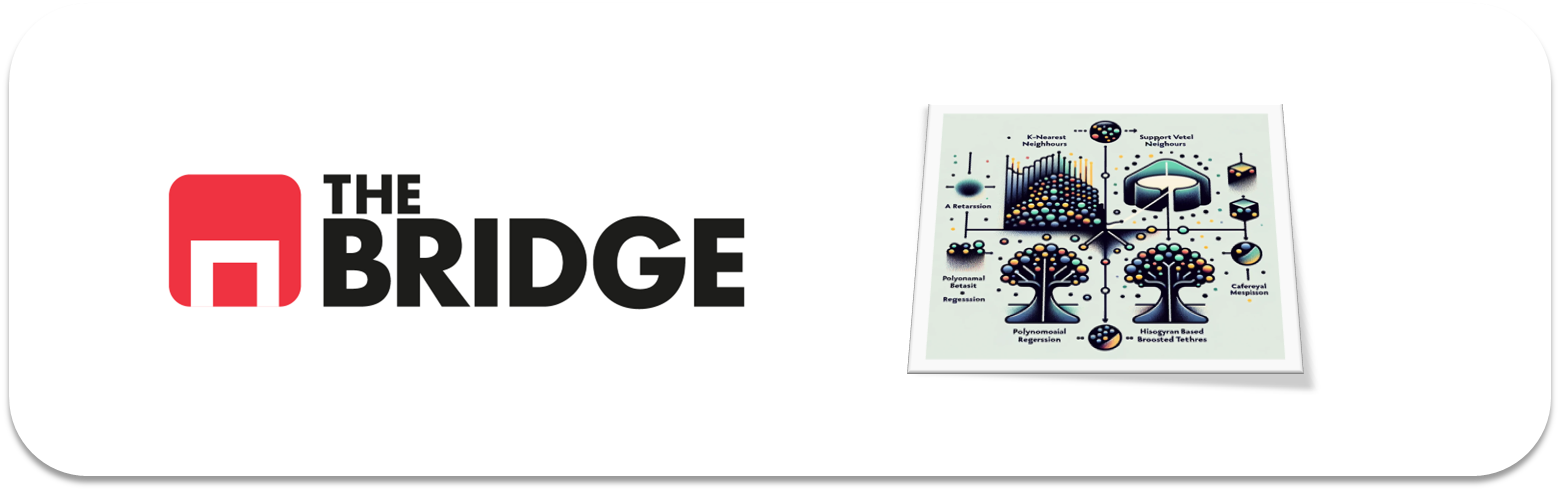

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
main_df = pd.read_csv("./data/credit_npo.csv")

In [3]:
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [4]:
main_df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


#### Variable objetivo (categórica/binaria)

SeriousDlqin2yrs — impago grave en 2 años (1/0)

#### Variables numéricas

- RevolvingUtilizationOfUnsecuredLines — uso de crédito disponible
- age — edad
- NumberOfTime30-59DaysPastDueNotWorse — retrasos de 30-59 días
- DebtRatio — ratio de endeudamiento
- MonthlyIncome — ingreso mensual
- NumberOfOpenCreditLinesAndLoans — líneas y préstamos abiertos
- NumberOfTimes90DaysLate — retrasos de 90+ días
- NumberRealEstateLoansOrLines — préstamos/líneas hipotecarias
- NumberOfTime60-89DaysPastDueNotWorse — retrasos de 60-89 días
- NumberOfDependents — nº de dependientes

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Se trata de un problema de clasificación binaria. La variable target sería `SeriousDlqin2yrs`

### #1.3
Pinta la distribución de frecuencias del target y coméntala

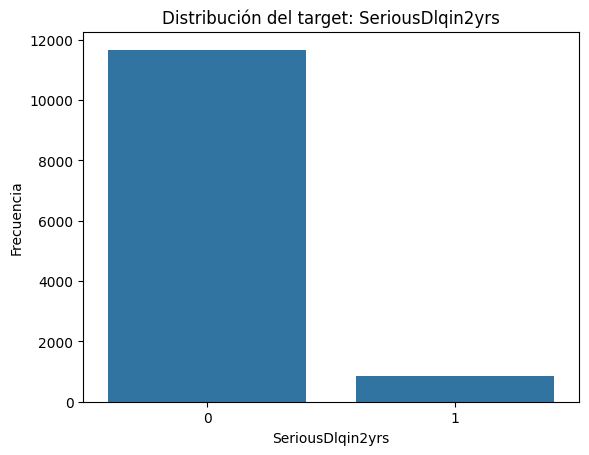

SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64


In [7]:
sns.countplot(data=main_df, x='SeriousDlqin2yrs')
plt.title('Distribución del target: SeriousDlqin2yrs')
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Frecuencia')
plt.show()

# Frecuencias exactas
print(main_df['SeriousDlqin2yrs'].value_counts())
print(main_df['SeriousDlqin2yrs'].value_counts(normalize=True))

Hay una infrarrepresentación de los casos de SeriousDlqin2yrs de valor 1, es decir, los casos en los que las personas tuvieron un impago serio.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [8]:
# División entre train y test
from sklearn.model_selection import train_test_split

X = main_df.drop(columns=['SeriousDlqin2yrs'])
y = main_df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(10029, 10) (2508, 10)
SeriousDlqin2yrs
0    0.9311
1    0.0689
Name: proportion, dtype: float64
SeriousDlqin2yrs
0    0.931021
1    0.068979
Name: proportion, dtype: float64


In [9]:
# Nulos
print(X_train.isnull().sum())

# Estadísticos básicos
X_train.describe()

# Correlación con el target (sobre train)
train_full = X_train.copy()
train_full['target'] = y_train
print(train_full.corr()['target'].sort_values(ascending=False))

RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           583
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      141
dtype: int64
target                                  1.000000
RevolvingUtilizationOfUnsecuredLines    0.280751
NumberOfTime30-59DaysPastDueNotWorse    0.089787
NumberOfTimes90DaysLate                 0.088104
NumberOfTime60-89DaysPastDueNotWorse    0.064196
NumberOfDependents                      0.048794
NumberRealEstateLoansOrLines           -0.001130
DebtRatio                              -0.020486
MonthlyIncome                          -0.029238
NumberOfOpenCreditLinesAndLoans        -0.031254
age                                    -0.115529
Name: ta

Vamos a ver si hay outliers en las dos variables con nulos para usar la mediana o la media para esos errores.

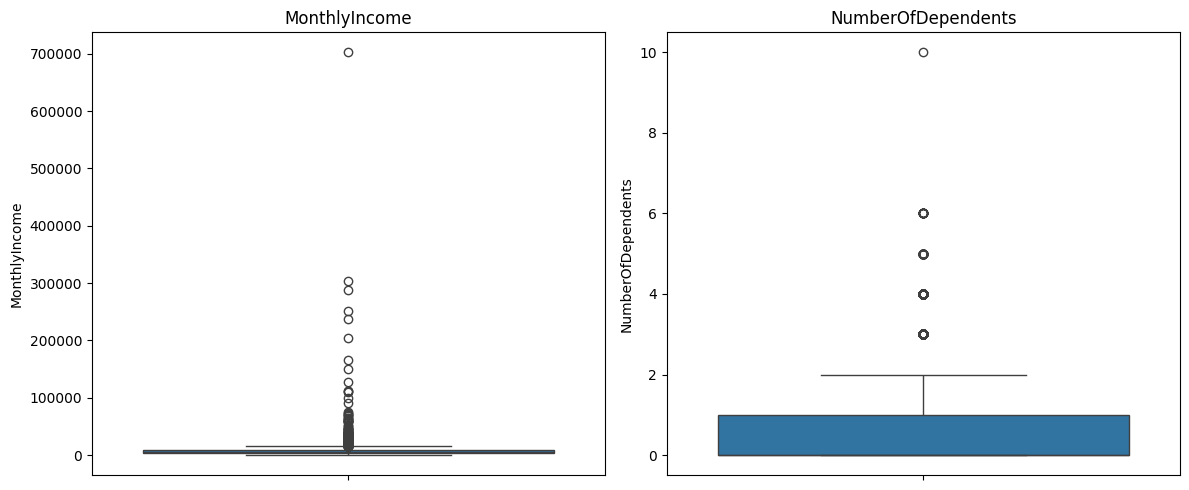

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=X_train, y='MonthlyIncome', ax=axes[0])
axes[0].set_title('MonthlyIncome')

sns.boxplot(data=X_train, y='NumberOfDependents', ax=axes[1])
axes[1].set_title('NumberOfDependents')

plt.tight_layout()
plt.show()

Como vemos que para MonthlyIncome hay numerosos outliers, utilizaremos la mediana para tratar los datos nulos.

In [14]:
mediana_income = X_train['MonthlyIncome'].median()
mediana_deps = X_train['NumberOfDependents'].median()

X_train['MonthlyIncome'] = X_train['MonthlyIncome'].fillna(mediana_income)
X_train['NumberOfDependents'] = X_train['NumberOfDependents'].fillna(mediana_deps)

# Usar los valores de TRAIN también en test (nunca recalcular con test)
X_test['MonthlyIncome'] = X_test['MonthlyIncome'].fillna(mediana_income)
X_test['NumberOfDependents'] = X_test['NumberOfDependents'].fillna(mediana_deps)

In [15]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

In [17]:
modelos = {
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

for nombre, modelo in modelos.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', modelo)
    ])
    scores = cross_val_score(pipe, X_train_scaled, y_train, cv=cv, scoring='recall', n_jobs=-1)
    resultados[nombre] = scores
    print(f"{nombre}: recall medio = {scores.mean():.4f} (+/- {scores.std():.4f})")

KNN: recall medio = 0.4992 (+/- 0.0352)
LogisticRegression: recall medio = 0.7423 (+/- 0.0296)
RandomForest: recall medio = 0.3009 (+/- 0.0310)
DecisionTree: recall medio = 0.3183 (+/- 0.0380)


In [ ]:
# Se aplica SMOTE en cada fold
pipe_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']  # soporta l1 y l2
}

grid = GridSearchCV(pipe_lr, param_grid, scoring='recall', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor recall (CV):", grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros: {'clf__C': 0.001, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Mejor recall (CV): 0.7813888020018769


c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.97      0.69      0.81      2335
           1       0.15      0.76      0.25       173

    accuracy                           0.69      2508
   macro avg       0.56      0.72      0.53      2508
weighted avg       0.92      0.69      0.77      2508



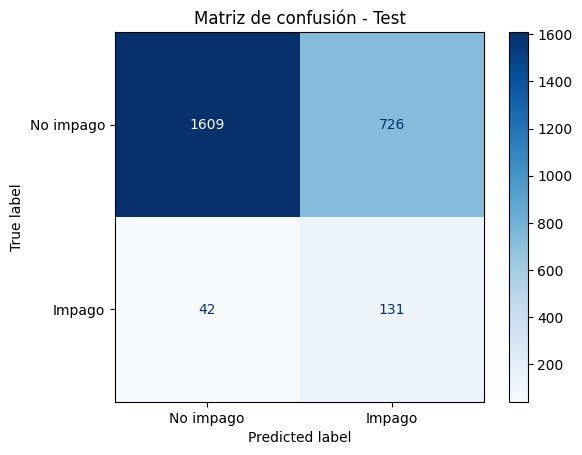

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No impago', 'Impago']).plot(cmap='Blues')
plt.title('Matriz de confusión - Test')
plt.show()

CONCLUSIONES

1. El modelo prioriza correctamente el recall de la clase minoritaria (76%), que era el objetivo del ejercicio.
2. La precisión muy baja (15%) indica que, en un caso real, este modelo generaría muchas revisiones manuales innecesarias — habría que valorar el coste de esos falsos positivos.
3. El macro avg f1-score (0.53) refleja el desequilibrio entre cómo de bien funciona el modelo en cada clase por separado.
4. Podría explorarse si ajustar el threshold de decisión (en vez de 0.5) permite encontrar un mejor equilibrio recall/precision según las necesidades del negocio.